In [1]:
# Import Pandas for data manipulation
import pandas as pd

# Import Matplotlib for visualization
import matplotlib.pyplot as plt

# Import the Breast Cancer dataset
from sklearn.datasets import load_breast_cancer

# Import train_test_split
from sklearn.model_selection import train_test_split

# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Import evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
# Load the Breast Cancer dataset
data = load_breast_cancer()

# Convert input features into a Pandas DataFrame
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

# Add target column
df["target"] = data.target

# Display first five rows
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [4]:
# Display number of rows and columns
print("Dataset Shape:")
print(df.shape)

# Display dataset information
print("\nDataset Information:")
df.info()

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(569, 31)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-

In [5]:
# 0 = Malignant
# 1 = Benign

In [6]:
# Check missing values in every column
print("Missing Values:")

print(
    df.isnull().sum()
)

Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [7]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print(
    "Number of Duplicate Records:",
    duplicate_count
)

Number of Duplicate Records: 0


In [8]:
# Remove duplicate rows
df = df.drop_duplicates()

# Display dataset shape
print(
    "Dataset Shape After Removing Duplicates:",
    df.shape
)

Dataset Shape After Removing Duplicates: (569, 31)


In [9]:
# Display number of samples in each class
print(
    df["target"].value_counts()
)

# Display target class names
print(
    data.target_names
)

target
1    357
0    212
Name: count, dtype: int64
['malignant' 'benign']


In [11]:
# x contains independent variables or input features
x = df.drop(
    "target",
    axis=1
)

# y contains dependent variable or target
y = df["target"]

# Display x shape
print(
    "x Shape:",
    x.shape
)

# Display y shape
print(
    "y Shape:",
    y.shape
)

x Shape: (569, 30)
y Shape: (569,)


In [12]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split dataset into training and testing data
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,       # 20% data used for testing
    random_state=42,      # Reproducible result
    stratify=y            # Maintain target class distribution
)

# Display training and testing data shapes
print(
    "x_train Shape:",
    x_train.shape
)

print(
    "x_test Shape:",
    x_test.shape
)

print(
    "y_train Shape:",
    y_train.shape
)

print(
    "y_test Shape:",
    y_test.shape
)

x_train Shape: (455, 30)
x_test Shape: (114, 30)
y_train Shape: (455,)
y_test Shape: (114,)


In [46]:
y_train

546    1
432    0
174    1
221    1
289    1
      ..
184    0
300    0
509    0
230    0
474    1
Name: target, Length: 455, dtype: int32

In [13]:
# x contains independent variables or input features
x = df.drop(
    "target",
    axis=1
)

# y contains dependent variable or target
y = df["target"]

# Display x shape
print(
    "x Shape:",
    x.shape
)

# Display y shape
print(
    "y Shape:",
    y.shape
)

x Shape: (569, 30)
y Shape: (569,)


In [14]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Learn mean and standard deviation
# from training data and scale training data
x_train_scaled = scaler.fit_transform(
    x_train
)

# Scale testing data using
# training data mean and standard deviation
x_test_scaled = scaler.transform(
    x_test
)

# Display scaled training data
print(
    x_train_scaled
)

[[-1.07200079 -0.6584246  -1.0880801  ... -1.35052668 -0.35265805
  -0.54138003]
 [ 1.74874285  0.06650173  1.75115682 ...  1.54991557  0.19107787
  -0.1737386 ]
 [-0.97473376 -0.93112416 -0.99770871 ... -1.70744192 -0.307734
  -1.21303263]
 ...
 [ 0.39844772  1.06867262  0.50751384 ...  1.53492543  0.16164487
   1.23754763]
 [ 0.85331409 -0.0380331   0.9054796  ...  2.10455077  0.31035897
   0.36249578]
 [-0.91179628 -0.82431683 -0.87666079 ... -0.51332734 -0.50756857
   1.30824791]]


In [ ]:
# fit_transform() is used only on training data.

# transform() is used on testing data.

# This prevents Data Leakage.

In [35]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000
)

# Train the model
logistic_model.fit(
    x_train_scaled,
    y_train
)

# Predict testing data
logistic_prediction = logistic_model.predict(
    x_test_scaled
)

# Display predictions
print(
    logistic_prediction
)

[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


In [16]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    penalty="l2",           # L2 Regularization
    C=1.0,                  # Inverse of regularization strength
    solver="liblinear",     # Optimization algorithm
    max_iter=1000,          # Maximum training iterations
    class_weight=None,      # No special class weights
    random_state=42         # Reproducible result
)

# Train Logistic Regression model
logistic_model.fit(
    x_train_scaled,
    y_train
)

# Predict testing data
logistic_prediction = logistic_model.predict(
    x_test_scaled
)

# Display predictions
print(
    logistic_prediction
)

[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


In [17]:
# Calculate Logistic Regression accuracy
logistic_accuracy = accuracy_score(
    y_test,
    logistic_prediction
)

# Display accuracy
print(
    "Logistic Regression Accuracy:",
    logistic_accuracy
)

Logistic Regression Accuracy: 0.9824561403508771


In [33]:
!pip install --upgrade threadpoolctl

  Obtaining dependency information for threadpoolctl from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 2.2.0
    Uninstalling threadpoolctl-2.2.0:
      Successfully uninstalled threadpoolctl-2.2.0


In [39]:
# Import KNN Classifier
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model with hyperparameters
knn_model = KNeighborsClassifier(
    n_neighbors=5,          # Number of nearest neighbors
    weights="distance",     # Closer neighbors get more importance
    algorithm="kd_tree",    # Use KD Tree search
    leaf_size=30,           # Leaf size of KD Tree
    p=2,                    # p=2 means Euclidean Distance
    metric="minkowski",     # Distance metric
    n_jobs=1                # Use one CPU core
)

# Train KNN model
knn_model.fit(
    x_train_scaled,
    y_train
)

# Predict testing data
knn_prediction = knn_model.predict(
    x_test_scaled
)

# Display predictions
print(knn_prediction)

[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1
 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


In [40]:
from sklearn.metrics import accuracy_score

knn_accuracy = accuracy_score(
    y_test,
    knn_prediction
)

print(
    "KNN Accuracy:",
    knn_accuracy
)

KNN Accuracy: 0.956140350877193


In [18]:
# Import Support Vector Classifier
from sklearn.svm import SVC

# Create SVM model
svm_model = SVC(
    C=1.0,                  # Regularization parameter
    kernel="rbf",           # Radial Basis Function Kernel
    degree=3,               # Degree used for Polynomial Kernel
    gamma="scale",          # Kernel coefficient
    coef0=0.0,              # Independent term
    shrinking=True,         # Use shrinking heuristic
    probability=True,       # Enable probability prediction
    class_weight=None,      # No special class weights
    random_state=42         # Reproducible result
)

# Train SVM model
svm_model.fit(
    x_train_scaled,
    y_train
)

# Predict testing data
svm_prediction = svm_model.predict(
    x_test_scaled
)

# Display predictions
print(
    svm_prediction
)

[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


In [19]:
# Calculate SVM accuracy
svm_accuracy = accuracy_score(
    y_test,
    svm_prediction
)

# Display SVM accuracy
print(
    "SVM Accuracy:",
    svm_accuracy
)

SVM Accuracy: 0.9824561403508771


In [54]:
type(df)

pandas.core.frame.DataFrame

In [53]:
type(y_test)

pandas.core.series.Series

In [52]:
Calculate SVM accuracy
svm_accuracy = accuracy_score(
    y_train,
    svm_prediction
)

# Display SVM accuracy
print(
    "SVM Accuracy:",
    svm_accuracy
)

In [20]:
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    criterion="gini",       # Split quality measurement
    splitter="best",        # Select the best split
    max_depth=5,            # Maximum depth of tree
    min_samples_split=2,    # Minimum samples required to split a node
    min_samples_leaf=1,     # Minimum samples required in a leaf
    max_features=None,      # Consider all features
    max_leaf_nodes=None,    # No maximum leaf node restriction
    class_weight=None,      # No special class weights
    ccp_alpha=0.0,          # Cost Complexity Pruning parameter
    random_state=42         # Reproducible result
)

# Train Decision Tree model
decision_tree_model.fit(
    x_train,
    y_train
)

# Predict testing data
decision_tree_prediction = decision_tree_model.predict(
    x_test
)

# Display predictions
print(
    decision_tree_prediction
)

[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 0 0 0 1
 0 1 0 1 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


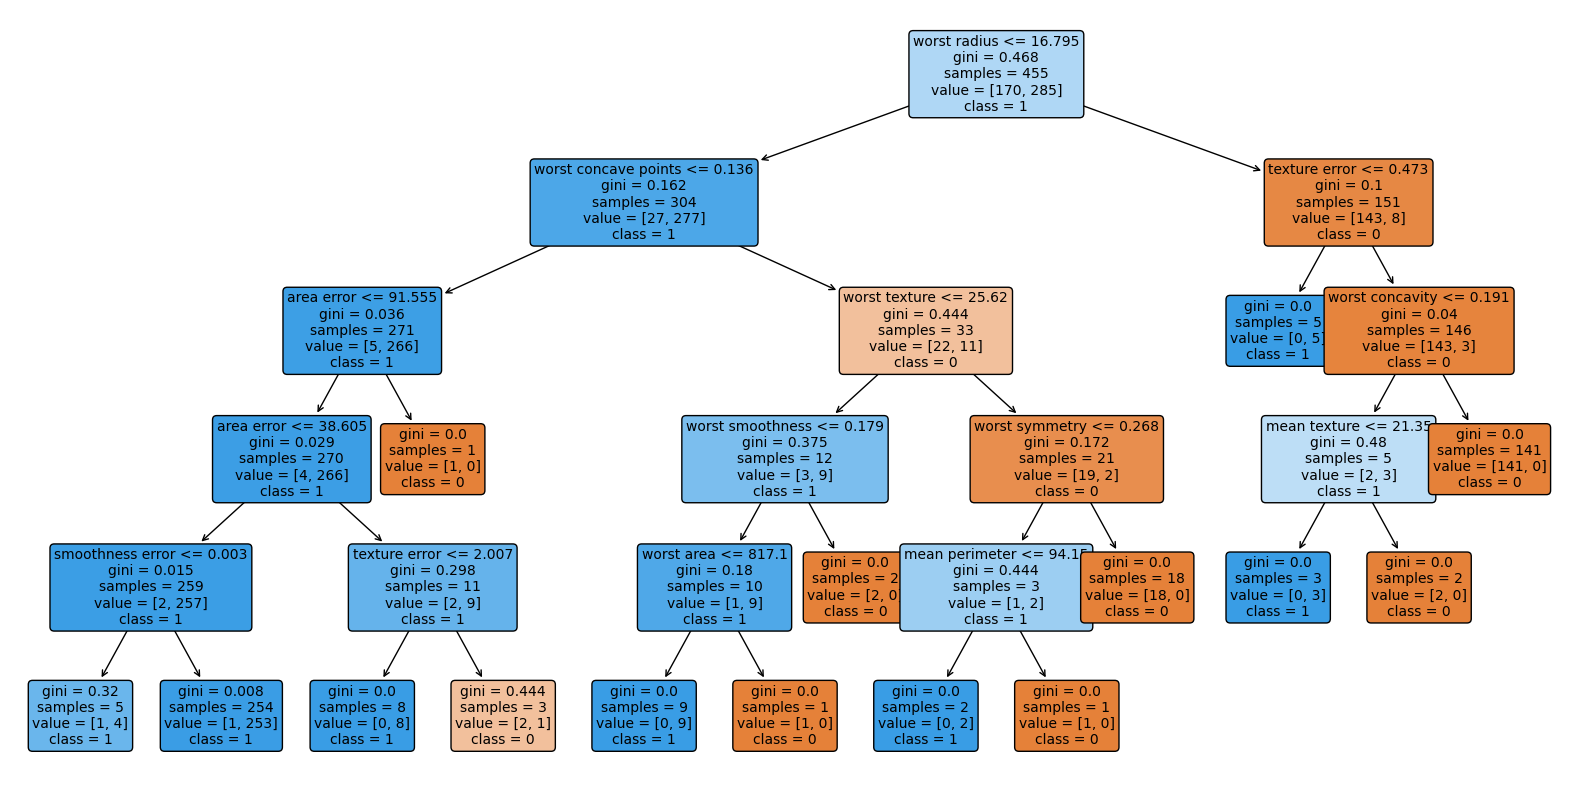

In [48]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    filled=True,
    feature_names=x_train.columns.tolist(),
    class_names=[str(i) for i in decision_tree_model.classes_],
    rounded=True,
    fontsize=10
)

plt.show()

In [21]:
# Calculate Decision Tree accuracy
decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_prediction
)

# Display Decision Tree accuracy
print(
    "Decision Tree Accuracy:",
    decision_tree_accuracy
)

Decision Tree Accuracy: 0.9210526315789473


In [22]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,       # Number of Decision Trees
    criterion="gini",       # Split quality measurement
    max_depth=10,           # Maximum depth of each tree
    min_samples_split=2,    # Minimum samples required to split a node
    min_samples_leaf=1,     # Minimum samples required in a leaf
    max_features="sqrt",    # Square root of total features considered
    bootstrap=True,         # Enable Bootstrap Sampling
    oob_score=True,         # Calculate Out-of-Bag Score
    class_weight=None,      # No special class weights
    n_jobs=-1,              # Use all CPU cores
    random_state=42         # Reproducible result
)

# Train Random Forest model
random_forest_model.fit(x_train,y_train)

# Predict testing data
random_forest_prediction = random_forest_model.predict(x_test)

# Display predictions
print(random_forest_prediction)

[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


In [23]:
# Calculate Random Forest accuracy
random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_prediction
)

# Display Random Forest accuracy
print(
    "Random Forest Accuracy:",
    random_forest_accuracy
)

# Display Out-of-Bag Score
print(
    "Random Forest OOB Score:",
    random_forest_model.oob_score_
)

Random Forest Accuracy: 0.956140350877193
Random Forest OOB Score: 0.9604395604395605


In [24]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [25]:
# Create a common function
# to evaluate all Machine Learning models
def evaluate_model(model_name,y_actual,y_predicted):
    # Calculate Accuracy
    accuracy = accuracy_score(y_actual,y_predicted)

    # Calculate Precision
    precision = precision_score(y_actual,y_predicted)

    # Calculate Recall
    recall = recall_score(y_actual,y_predicted)

    # Calculate F1 Score
    f1 = f1_score(y_actual,y_predicted)

    # Calculate Confusion Matrix
    cm = confusion_matrix(y_actual,y_predicted)

    # Display model name
    print("\n==============================")

    print("MODEL:",model_name)

    print("==============================")

    # Display Accuracy
    print("Accuracy:",accuracy)

    # Display Precision
    print("Precision:",precision)

    # Display Recall
    print("Recall:",recall)

    # Display F1 Score
    print("F1 Score:",f1)

    # Display Confusion Matrix
    print("\nConfusion Matrix:")

    print(cm)

    # Display Classification Report
    print("\nClassification Report:")

    print(
        classification_report(
            y_actual,
            y_predicted
        )
    )

In [41]:
evaluate_model(
    "K-Nearest Neighbors",
    y_test,
    knn_prediction
)


MODEL: K-Nearest Neighbors
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104

Confusion Matrix:
[[39  3]
 [ 2 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [27]:
evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_prediction
)


MODEL: Logistic Regression
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [28]:
evaluate_model(
    "Support Vector Machine",
    y_test,
    svm_prediction
)


MODEL: Support Vector Machine
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [29]:
evaluate_model(
    "Decision Tree",
    y_test,
    decision_tree_prediction
)


MODEL: Decision Tree
Accuracy: 0.9210526315789473
Precision: 0.9565217391304348
Recall: 0.9166666666666666
F1 Score: 0.9361702127659574

Confusion Matrix:
[[39  3]
 [ 6 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [30]:
evaluate_model(
    "Random Forest",
    y_test,
    random_forest_prediction
)


MODEL: Random Forest
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104

Confusion Matrix:
[[39  3]
 [ 2 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [42]:
# Store model accuracy scores
model_results = {
    "KNN": knn_accuracy,
    "Logistic Regression": logistic_accuracy,
    "SVM": svm_accuracy,
    "Decision Tree": decision_tree_accuracy,
    "Random Forest": random_forest_accuracy
}

# Convert dictionary into Pandas DataFrame
performance_df = pd.DataFrame(
    model_results.items(),
    columns=[
        "Algorithm",
        "Accuracy"
    ]
)

# Sort algorithms based on accuracy
performance_df = performance_df.sort_values(
    by="Accuracy",
    ascending=False
)

# Display model performance
print(
    performance_df
)

             Algorithm  Accuracy
1  Logistic Regression  0.982456
2                  SVM  0.982456
0                  KNN  0.956140
4        Random Forest  0.956140
3        Decision Tree  0.921053


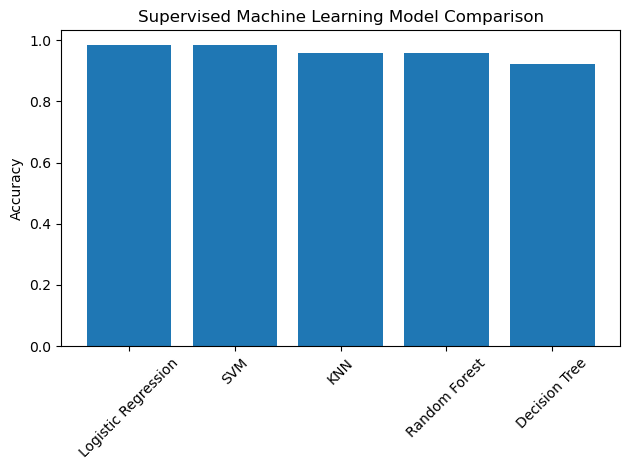

In [43]:
# Import Matplotlib
import matplotlib.pyplot as plt

# Create bar graph
plt.bar(
    performance_df["Algorithm"],
    performance_df["Accuracy"]
)

# Rotate algorithm names
plt.xticks(
    rotation=45
)

# Add Y-axis label
plt.ylabel(
    "Accuracy"
)

# Add graph title
plt.title(
    "Supervised Machine Learning Model Comparison"
)

# Adjust graph layout
plt.tight_layout()

# Display graph
plt.show()

In [55]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

In [56]:
# Complete evaluation function for classification models
def complete_evaluation(
    model_name,
    model,
    x_test_data,
    y_actual,
    y_predicted
):

    # Calculate classification metrics
    accuracy = accuracy_score(y_actual, y_predicted)
    precision = precision_score(y_actual, y_predicted)
    recall = recall_score(y_actual, y_predicted)
    f1 = f1_score(y_actual, y_predicted)

    # Display model name and metrics
    print("\n===================================")
    print("MODEL:", model_name)
    print("===================================")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    # Display Confusion Matrix values
    cm = confusion_matrix(y_actual, y_predicted)

    print("\nConfusion Matrix:")
    print(cm)

    # Display Classification Report
    print("\nClassification Report:")
    print(
        classification_report(
            y_actual,
            y_predicted,
            target_names=["Malignant", "Benign"]
        )
    )

    # Plot Confusion Matrix
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Malignant", "Benign"]
    ).plot()

    plt.title(model_name + " - Confusion Matrix")
    plt.show()

    # Obtain probability or decision score for ROC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(x_test_data)[:, 1]
    else:
        y_score = model.decision_function(x_test_data)

    # Calculate ROC Curve and ROC-AUC
    fpr, tpr, thresholds = roc_curve(
        y_actual,
        y_score
    )

    auc_score = roc_auc_score(
        y_actual,
        y_score
    )

    # Plot ROC Curve
    plt.figure(figsize=(7, 5))

    plt.plot(
        fpr,
        tpr,
        label=f"ROC-AUC = {auc_score:.3f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(model_name + " - ROC Curve")
    plt.legend()
    plt.show()

    print("ROC-AUC :", auc_score)



MODEL: Logistic Regression
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



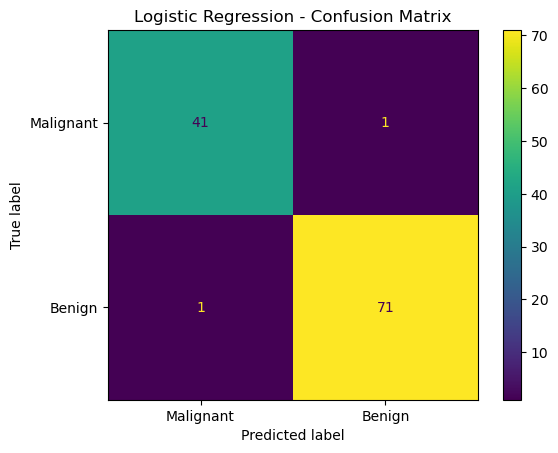

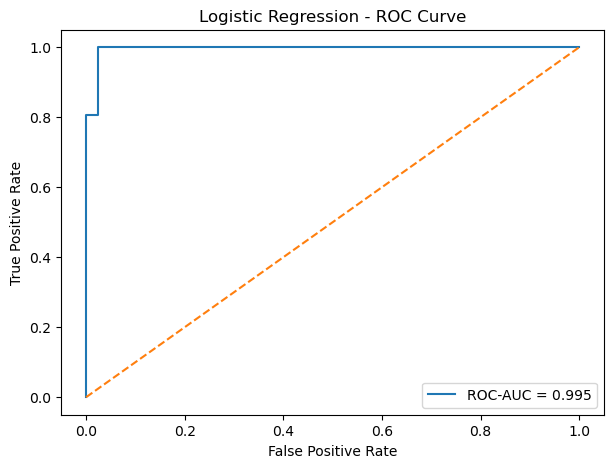

ROC-AUC : 0.9953703703703703


In [57]:
# Evaluate Logistic Regression
complete_evaluation(
    "Logistic Regression",
    logistic_model,
    x_test_scaled,
    y_test,
    logistic_prediction
)



MODEL: K-Nearest Neighbors
Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1 Score : 0.9655172413793104

Confusion Matrix:
[[39  3]
 [ 2 70]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



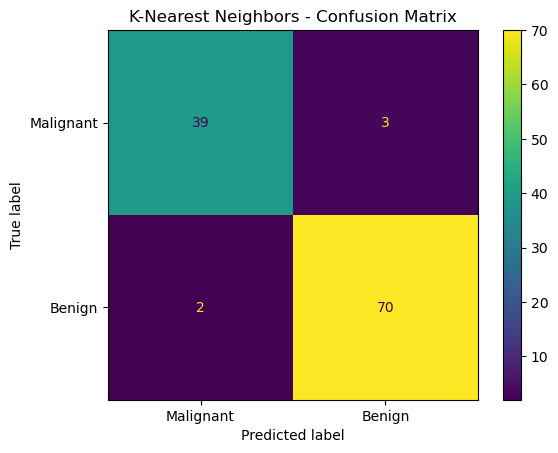

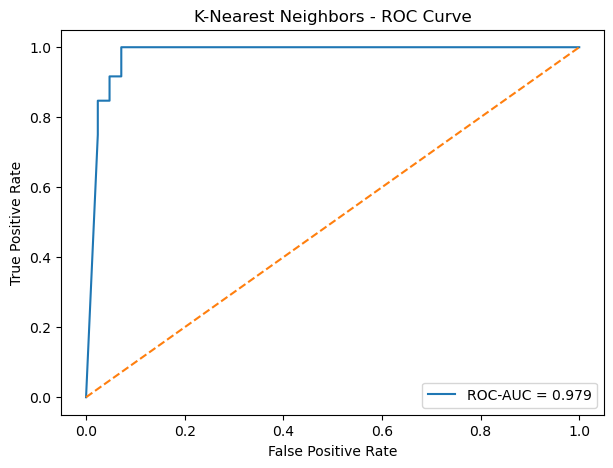

ROC-AUC : 0.9794973544973545


In [58]:
# Evaluate K-Nearest Neighbors
complete_evaluation(
    "K-Nearest Neighbors",
    knn_model,
    x_test_scaled,
    y_test,
    knn_prediction
)


MODEL: Support Vector Machine
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



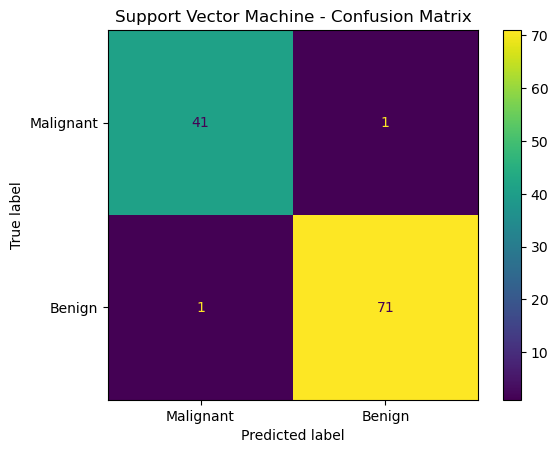

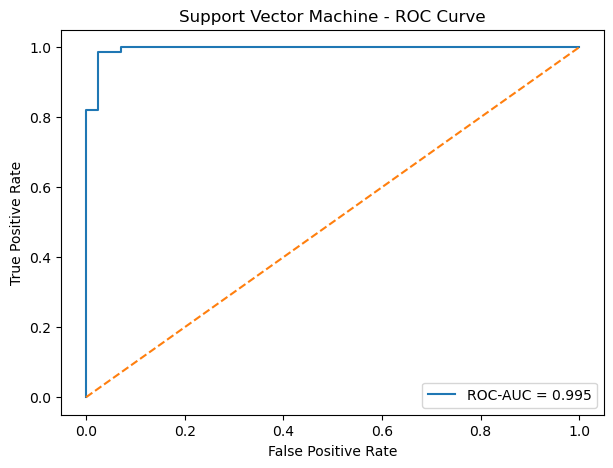

ROC-AUC : 0.9950396825396826


In [59]:
# Evaluate Support Vector Machine
complete_evaluation(
    "Support Vector Machine",
    svm_model,
    x_test_scaled,
    y_test,
    svm_prediction
)


MODEL: Decision Tree
Accuracy : 0.9210526315789473
Precision: 0.9565217391304348
Recall   : 0.9166666666666666
F1 Score : 0.9361702127659574

Confusion Matrix:
[[39  3]
 [ 6 66]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.87      0.93      0.90        42
      Benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



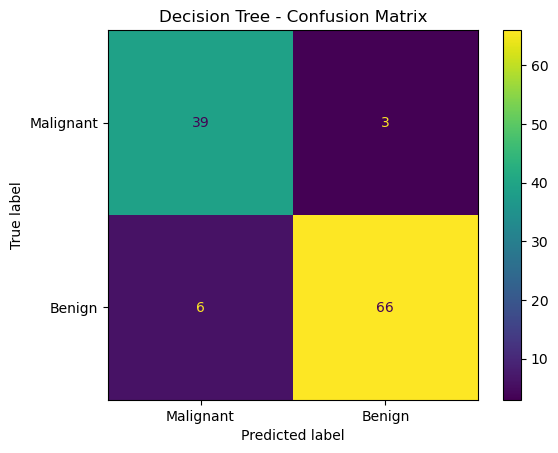

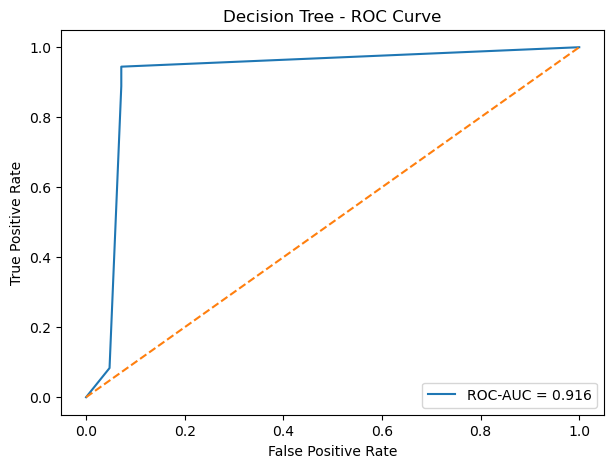

ROC-AUC : 0.9163359788359788


In [60]:
# Evaluate Decision Tree
complete_evaluation(
    "Decision Tree",
    decision_tree_model,
    x_test,
    y_test,
    decision_tree_prediction
)


In [2]:
'''| Hyperparameter      | Purpose                                              | Common Value          |
| ------------------- | ---------------------------------------------------- | --------------------- |
| `n_estimators`      | Number of decision trees                             | 100, 200              |
| `criterion`         | Split quality measure                                | `"gini"`, `"entropy"` |
| `max_depth`         | Maximum depth of each tree                           | 5–20                  |
| `min_samples_split` | Minimum samples required to split a node             | 2, 5, 10              |
| `min_samples_leaf`  | Minimum samples in each leaf                         | 1, 2, 5               |
| `max_features`      | Number of features considered at each split          | `"sqrt"`              |
| `bootstrap`         | Use bootstrap sampling                               | `True`                |
| `max_samples`       | Number/proportion of samples for each bootstrap tree | `0.7`, `0.8`, `None`  |
| `oob_score`         | Enable Out-of-Bag evaluation                         | `True`                |
| `class_weight`      | Assign weights to classes                            | `"balanced"`          |
| `n_jobs`            | Number of CPU cores used                             | `-1`                  |
| `random_state`      | Ensures reproducible results                         | `42`                  |
'''

'| Hyperparameter      | Purpose                                              | Common Value          |\n| ------------------- | ---------------------------------------------------- | --------------------- |\n| `n_estimators`      | Number of decision trees                             | 100, 200              |\n| `criterion`         | Split quality measure                                | `"gini"`, `"entropy"` |\n| `max_depth`         | Maximum depth of each tree                           | 5–20                  |\n| `min_samples_split` | Minimum samples required to split a node             | 2, 5, 10              |\n| `min_samples_leaf`  | Minimum samples in each leaf                         | 1, 2, 5               |\n| `max_features`      | Number of features considered at each split          | `"sqrt"`              |\n| `bootstrap`         | Use bootstrap sampling                               | `True`                |\n| `max_samples`       | Number/proportion of samples for each b


MODEL: Random Forest
Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1 Score : 0.9655172413793104

Confusion Matrix:
[[39  3]
 [ 2 70]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



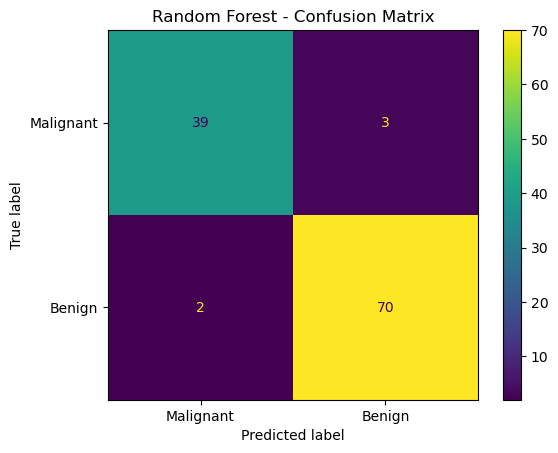

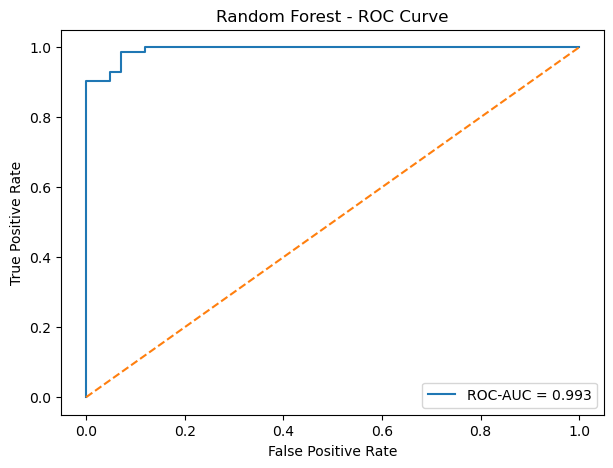

ROC-AUC : 0.9930555555555556


In [61]:
# Evaluate Random Forest
complete_evaluation(
    "Random Forest",
    random_forest_model,
    x_test,
    y_test,
    random_forest_prediction
)